# 05 Detección de Zonas de Riesgo - DBSCAN
**Curso:** Agentes Inteligentes | **Grupo 5**

### Estructura del notebook

| Sección | Descripción | Input |
|---|---|---|
| 1. Carga y verificación | Dataset completo sin SMOTE | `siniestros_modelado.csv` |
| 2. Extracción de coordenadas | Latitud y longitud originales | `df` |
| 3. Normalización | Copia para DBSCAN - coordenadas originales intactas | `coords_norm` |
| 4. Selección de parámetros | K-distance plot para `eps` óptimo | `coords_norm` |
| 5. DBSCAN | Clustering espacial | `coords_norm` |
| 6. Análisis de clusters | Severidad por cluster, ruido | `df` + labels |
| 7. Visualización geográfica | Mapa sobre coordenadas reales | `df` |
| 8. Interpretación | Hallazgos conectados a pregunta de investigación | - |
| 9. Exportación | Dataset con cluster asignado | `siniestros_clusters.csv` |

> **Fuente metodológica:** Kamh et al. - clustering espacial de hotspots viales.
> Ester et al. (1996) - selección de parámetros DBSCAN via k-distance plot.
> Han et al. (2012) - normalización obligatoria previa a algoritmos de distancia.


In [2]:
import sys
print(sys.executable)

/home/node-vault07/projects/siniestros-fatales-peru-ml/.venv/bin/python


## 0. Imports y configuración

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent

DIR_PROCESADA = BASE_DIR / 'data' / 'procesada'
DIR_FIGURAS   = BASE_DIR / 'outputs' / 'figures'
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)


## 1. Carga y verificación

Se carga `siniestros_modelado.csv` - el dataset completo sin SMOTE exportado
por el Notebook 03. Este archivo contiene las features encodeadas y la variable
objetivo, pero las coordenadas deben verificarse como numéricas reales antes
de cualquier operación espacial.


In [4]:
df = pd.read_csv(DIR_PROCESADA / 'siniestros_modelado.csv', encoding='utf-8')

print(f'Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Nulos: {df.isnull().sum().sum()}')

# Detectar columnas dinámicamente
col_lat    = next((c for c in df.columns if 'LATITUD'   in c.upper()), None)
col_lon    = next((c for c in df.columns if 'LONGITUD'  in c.upper()), None)
col_target = next((c for c in df.columns if c == 'CATEGORIA_SEVERIDAD'), None)

print(f'\nColumna latitud detectada:  {col_lat}')
print(f'Columna longitud detectada: {col_lon}')
print(f'Variable objetivo detectada: {col_target}')

# Assert: coordenadas deben ser numéricas reales
# El notebook 03 las pudo encodear si pandas las interpretó como object
assert col_lat and col_lon, 'No se encontraron columnas de coordenadas.'
assert pd.api.types.is_numeric_dtype(df[col_lat]), f'{col_lat} no es numérica - verificar encoding en N03.'
assert pd.api.types.is_numeric_dtype(df[col_lon]), f'{col_lon} no es numérica - verificar encoding en N03.'
assert col_target, 'No se encontró CATEGORIA_SEVERIDAD.'

# Verificar rango geográfico coherente con territorio peruano
lat_min, lat_max = df[col_lat].min(), df[col_lat].max()
lon_min, lon_max = df[col_lon].min(), df[col_lon].max()
print(f'\nRango latitud:  [{lat_min:.4f}, {lat_max:.4f}] (Perú esperado: -18.5 a 0.0)')
print(f'Rango longitud: [{lon_min:.4f}, {lon_max:.4f}] (Perú esperado: -81.5 a -68.5)')

assert -19 < lat_min and lat_max < 0,   '[WARNING] Latitud fuera del rango peruano - revisar encoding.'
assert -82 < lon_min and lon_max < -68, '[WARNING] Longitud fuera del rango peruano - revisar encoding.'

print('\n[SUCCESS] Coordenadas verificadas como numéricas y dentro del territorio peruano.')
print(f'\nDistribución de {col_target}:')
print(df[col_target].value_counts())


Dimensiones: 9,106 filas × 81 columnas
Nulos: 0

Columna latitud detectada:  COORDENADAS LATITUD
Columna longitud detectada: COORDENADAS  LONGITUD
Variable objetivo detectada: CATEGORIA_SEVERIDAD

Rango latitud:  [-18.3054, -3.4829] (Perú esperado: -18.5 a 0.0)
Rango longitud: [-81.2889, -68.9531] (Perú esperado: -81.5 a -68.5)

[SUCCESS] Coordenadas verificadas como numéricas y dentro del territorio peruano.

Distribución de CATEGORIA_SEVERIDAD:
CATEGORIA_SEVERIDAD
LEVE                7652
GRAVE_MORTALIDAD     929
GRAVE_LESIONADOS     525
Name: count, dtype: int64


## 2. Extracción de coordenadas originales

Se extraen las coordenadas en un objeto separado para preservarlas intactas.
El objeto `coords_orig` se usará para las visualizaciones geográficas.
El objeto `coords_norm` se usará exclusivamente para DBSCAN.

In [5]:
# Eliminar filas con coordenadas nulas si las hubiera
n_antes = len(df)
df = df.dropna(subset=[col_lat, col_lon]).reset_index(drop=True)
n_eliminadas = n_antes - len(df)
if n_eliminadas > 0:
    print(f'[WARNING] {n_eliminadas} filas eliminadas por coordenadas nulas.')
else:
    print('[SUCCESS] Sin filas eliminadas - todas las coordenadas son válidas.')

# Coordenadas originales - para mapas
coords_orig = df[[col_lat, col_lon]].values

print(f'\nRegistros disponibles para clustering: {len(coords_orig):,}')
print(f'Shape coords_orig: {coords_orig.shape}')


[SUCCESS] Sin filas eliminadas - todas las coordenadas son válidas.

Registros disponibles para clustering: 9,106
Shape coords_orig: (9106, 2)


## 3. Normalización

DBSCAN usa distancia euclidiana. En el territorio peruano, un grado de latitud
equivale a ~111 km, pero un grado de longitud equivale a ~85 km en el ecuador
y menos hacia el sur. Sin normalización, DBSCAN trataría ambas dimensiones como
equivalentes, distorsionando los clusters (Han et al., 2012).

Se normaliza con `StandardScaler` sobre una **copia** de las coordenadas.
Las coordenadas originales (`coords_orig`) permanecen intactas para los mapas.


In [6]:
scaler = StandardScaler()
coords_norm = scaler.fit_transform(coords_orig)

print('Normalización aplicada con StandardScaler.')
print(f'Media latitud normalizada:   {coords_norm[:,0].mean():.4f} (debe ser ~0)')
print(f'Std latitud normalizada:     {coords_norm[:,0].std():.4f} (debe ser ~1)')
print(f'Media longitud normalizada:  {coords_norm[:,1].mean():.4f} (debe ser ~0)')
print(f'Std longitud normalizada:    {coords_norm[:,1].std():.4f} (debe ser ~1)')


Normalización aplicada con StandardScaler.
Media latitud normalizada:   0.0000 (debe ser ~0)
Std latitud normalizada:     1.0000 (debe ser ~1)
Media longitud normalizada:  0.0000 (debe ser ~0)
Std longitud normalizada:    1.0000 (debe ser ~1)


## 4. Selección de parámetros - K-distance plot

DBSCAN requiere dos parámetros: `eps` (radio de vecindad) y `min_samples`
(mínimo de puntos para formar un cluster). Hardcodearlos sin análisis previo
produce resultados arbitrarios.

**Método:** k-distance plot (Ester et al., 1996). Se calcula la distancia
al k-ésimo vecino más cercano para cada punto, se ordenan de mayor a menor
y se busca el "codo" - el punto donde la curva cambia de pendiente bruscamente.
Ese valor es el `eps` óptimo. `k = min_samples - 1`.

Se evalúan dos valores de `min_samples` para comparar granularidad.


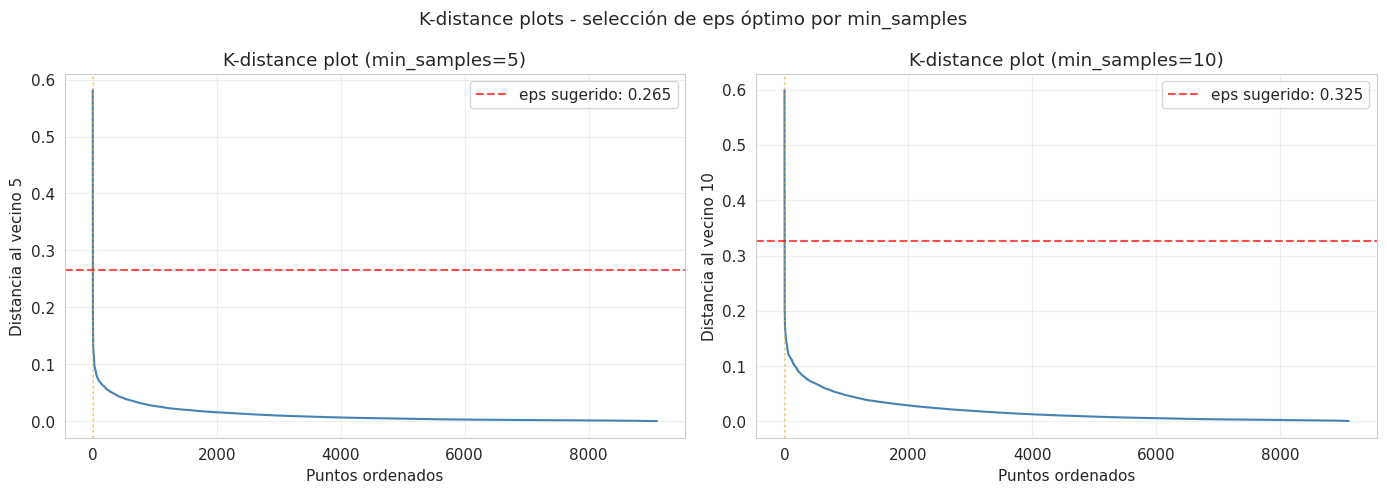


Eps recomendados por min_samples:
  min_samples=5: eps=0.2652
  min_samples=10: eps=0.3254

Nota: el codo detectado automáticamente es una guía.
Ajustar manualmente si el plot muestra un codo más claro en otro punto.


In [7]:
# Evaluar dos valores de min_samples
MIN_SAMPLES_CANDIDATOS = [5, 10]
fig, axes = plt.subplots(1, len(MIN_SAMPLES_CANDIDATOS), figsize=(14, 5))

eps_recomendados = {}

for ax, ms in zip(axes, MIN_SAMPLES_CANDIDATOS):
    nbrs = NearestNeighbors(n_neighbors=ms).fit(coords_norm)
    distancias, _ = nbrs.kneighbors(coords_norm)
    dist_k = np.sort(distancias[:, ms-1])[::-1]

    ax.plot(dist_k, linewidth=1.5, color='steelblue')
    ax.set_title(f'K-distance plot (min_samples={ms})')
    ax.set_xlabel('Puntos ordenados')
    ax.set_ylabel(f'Distancia al vecino {ms}')
    ax.grid(True, alpha=0.3)

    # Detectar codo automáticamente por máxima curvatura
    diffs = np.diff(dist_k)
    codo_idx = np.argmax(np.abs(np.diff(diffs))) + 1
    eps_codo = dist_k[codo_idx]
    eps_recomendados[ms] = eps_codo
    ax.axhline(eps_codo, color='red', linestyle='--', alpha=0.7,
               label=f'eps sugerido: {eps_codo:.3f}')
    ax.axvline(codo_idx, color='orange', linestyle=':', alpha=0.5)
    ax.legend()

plt.suptitle('K-distance plots - selección de eps óptimo por min_samples')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / 'kdistance_dbscan.png', dpi=150)
plt.show()

print('\nEps recomendados por min_samples:')
for ms, eps in eps_recomendados.items():
    print(f'  min_samples={ms}: eps={eps:.4f}')
print('\nNota: el codo detectado automáticamente es una guía.')
print('Ajustar manualmente si el plot muestra un codo más claro en otro punto.')


In [8]:
# Selección final de parámetros
# Modificar estos valores si el k-distance plot sugiere un codo distinto
MIN_SAMPLES = 5
EPS = eps_recomendados[MIN_SAMPLES]

print(f'Parámetros seleccionados:')
print(f'  eps         = {EPS:.4f}')
print(f'  min_samples = {MIN_SAMPLES}')
print(f'\nEstos valores se derivan del k-distance plot - no son hardcodeados.')


Parámetros seleccionados:
  eps         = 0.2652
  min_samples = 5

Estos valores se derivan del k-distance plot - no son hardcodeados.


## 5. Aplicación de DBSCAN

DBSCAN clasifica cada punto como:
- **Core point**: tiene al menos `min_samples` vecinos dentro de `eps`
- **Border point**: está dentro del `eps` de un core point pero no es core
- **Ruido** (label = -1): no pertenece a ningún cluster

Los puntos de ruido no se ignoran - se reportan y analizan porque pueden
representar siniestros aislados en zonas remotas (Ester et al., 1996).


In [9]:
db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
labels = db.fit_predict(coords_norm)

# Asignar labels al dataframe original
df['CLUSTER'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_ruido    = (labels == -1).sum()

print(f'Clusters encontrados: {n_clusters}')
print(f'Puntos de ruido:      {n_ruido:,} ({n_ruido/len(labels)*100:.1f}%)')
print(f'Puntos en clusters:   {(labels != -1).sum():,} ({(labels != -1).sum()/len(labels)*100:.1f}%)')
print(f'\nTamaño de clusters:')
for cl in sorted(set(labels)):
    n = (labels == cl).sum()
    nombre = 'RUIDO' if cl == -1 else f'Cluster {cl}'
    print(f'  {nombre}: {n:,} puntos')


Clusters encontrados: 3
Puntos de ruido:      1 (0.0%)
Puntos en clusters:   9,105 (100.0%)

Tamaño de clusters:
  RUIDO: 1 puntos
  Cluster 0: 8,997 puntos
  Cluster 1: 42 puntos
  Cluster 2: 66 puntos


## 6. Análisis de severidad por cluster

Se analiza la distribución de `CATEGORIA_SEVERIDAD` dentro de cada cluster
para identificar cuáles concentran mayor proporción de siniestros graves.


In [10]:
# Distribución de severidad por cluster
resumen_clusters = df.groupby('CLUSTER')[col_target].value_counts(normalize=True).unstack(fill_value=0)
resumen_clusters['TOTAL'] = df.groupby('CLUSTER').size()
resumen_clusters = resumen_clusters.sort_values('TOTAL', ascending=False)

print('=== Proporción de severidad por cluster ===')
print(resumen_clusters.round(3).to_string())

# Identificar clusters con alta proporción de casos graves
col_grave = 'GRAVE_MORTALIDAD' if 'GRAVE_MORTALIDAD' in resumen_clusters.columns else None
if col_grave:
    umbral = resumen_clusters[col_grave].mean() * 1.5
    clusters_criticos = resumen_clusters[resumen_clusters[col_grave] > umbral].index.tolist()
    clusters_criticos = [c for c in clusters_criticos if c != -1]
    print(f'\nClusters con proporción de GRAVE_MORTALIDAD > {umbral:.2f} (1.5x la media):')
    print(f'  {clusters_criticos}')


=== Proporción de severidad por cluster ===
CATEGORIA_SEVERIDAD  GRAVE_LESIONADOS  GRAVE_MORTALIDAD   LEVE  TOTAL
CLUSTER                                                              
 0                              0.058             0.103  0.839   8997
 2                              0.015             0.030  0.955     66
 1                              0.024             0.048  0.929     42
-1                              0.000             0.000  1.000      1

Clusters con proporción de GRAVE_MORTALIDAD > 0.07 (1.5x la media):
  [0]


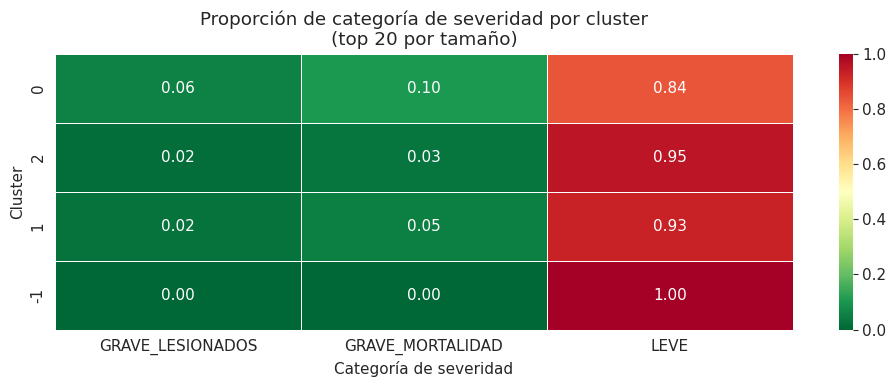

In [11]:
# Heatmap de severidad por cluster (top 20 clusters más grandes)
top_clusters = resumen_clusters.head(20).drop(columns=['TOTAL'], errors='ignore')

if not top_clusters.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(top_clusters) * 0.4)))
    sns.heatmap(top_clusters, annot=True, fmt='.2f', cmap='RdYlGn_r',
                ax=ax, linewidths=0.5)
    ax.set_title('Proporción de categoría de severidad por cluster\n(top 20 por tamaño)')
    ax.set_xlabel('Categoría de severidad')
    ax.set_ylabel('Cluster')
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / 'severidad_por_cluster.png', dpi=150)
    plt.show()


## 7. Visualización geográfica

Los mapas usan las **coordenadas originales** - no las normalizadas.
Se generan dos visualizaciones: clusters detectados y severidad por punto.


/tmp/ipykernel_4283/287889307.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(len(clusters_unicos), 1))


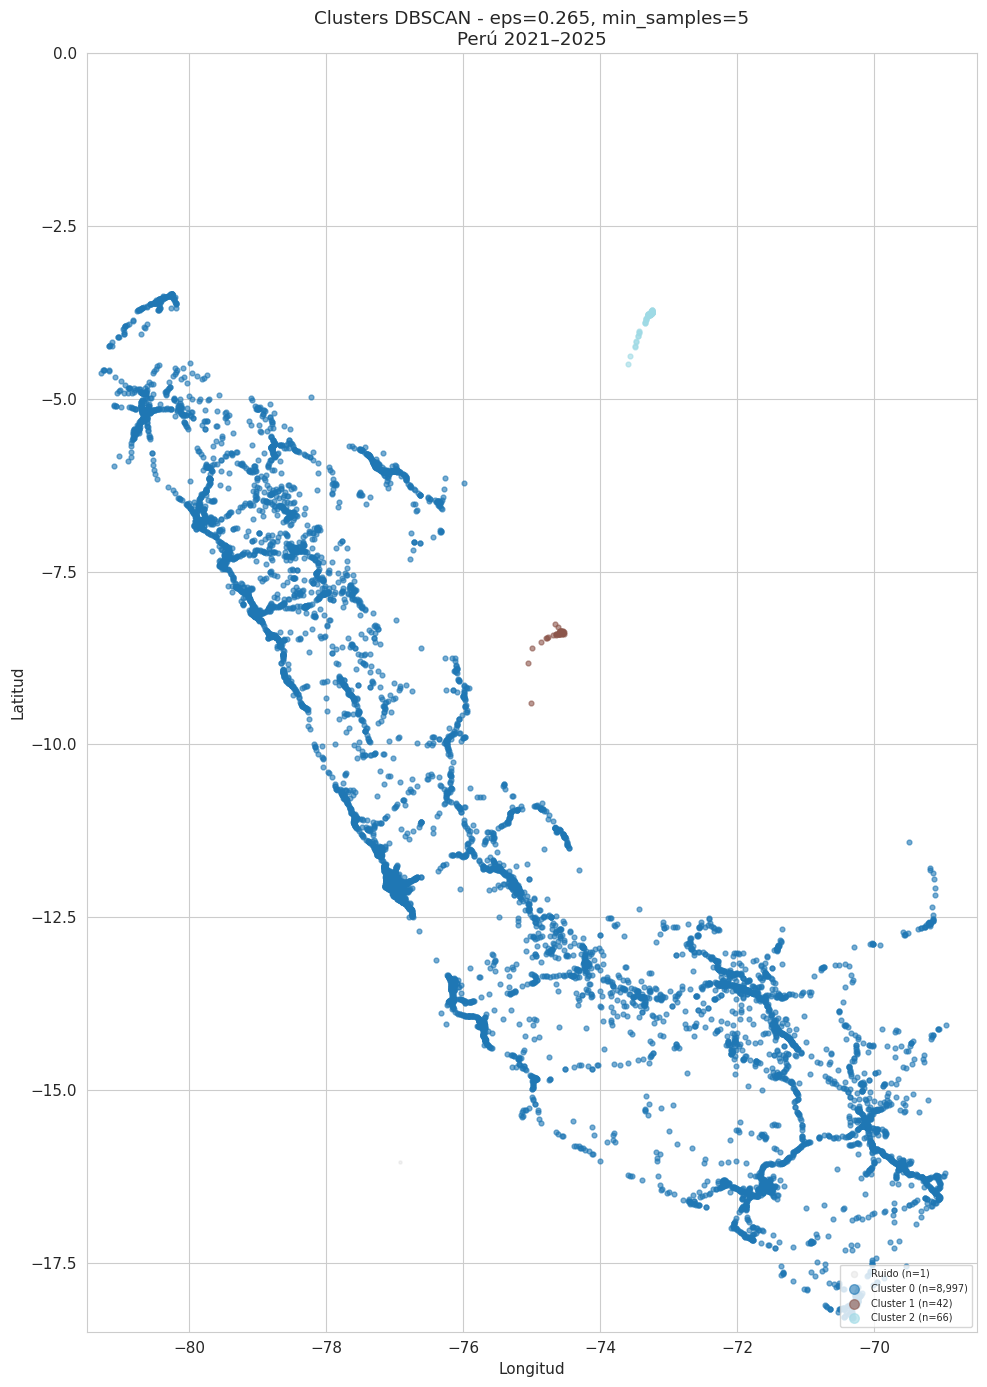

In [12]:
# Mapa 1: clusters detectados
fig, ax = plt.subplots(figsize=(10, 14))

# Ruido en gris
ruido = df[df['CLUSTER'] == -1]
ax.scatter(ruido[col_lon], ruido[col_lat],
           c='lightgray', s=5, alpha=0.3, label=f'Ruido (n={len(ruido):,})')

# Clusters con colores distintos
clusters_unicos = sorted([c for c in df['CLUSTER'].unique() if c != -1])
cmap = plt.cm.get_cmap('tab20', max(len(clusters_unicos), 1))

for i, cl in enumerate(clusters_unicos):
    subset = df[df['CLUSTER'] == cl]
    ax.scatter(subset[col_lon], subset[col_lat],
               c=[cmap(i)], s=12, alpha=0.6,
               label=f'Cluster {cl} (n={len(subset):,})')

ax.set_xlim(-81.5, -68.5)
ax.set_ylim(-18.5, -0.0)
ax.set_title(f'Clusters DBSCAN - eps={EPS:.3f}, min_samples={MIN_SAMPLES}\nPerú 2021–2025')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
if len(clusters_unicos) <= 15:
    ax.legend(loc='lower right', fontsize=7, markerscale=2)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / 'mapa_clusters_dbscan.png', dpi=150)
plt.show()


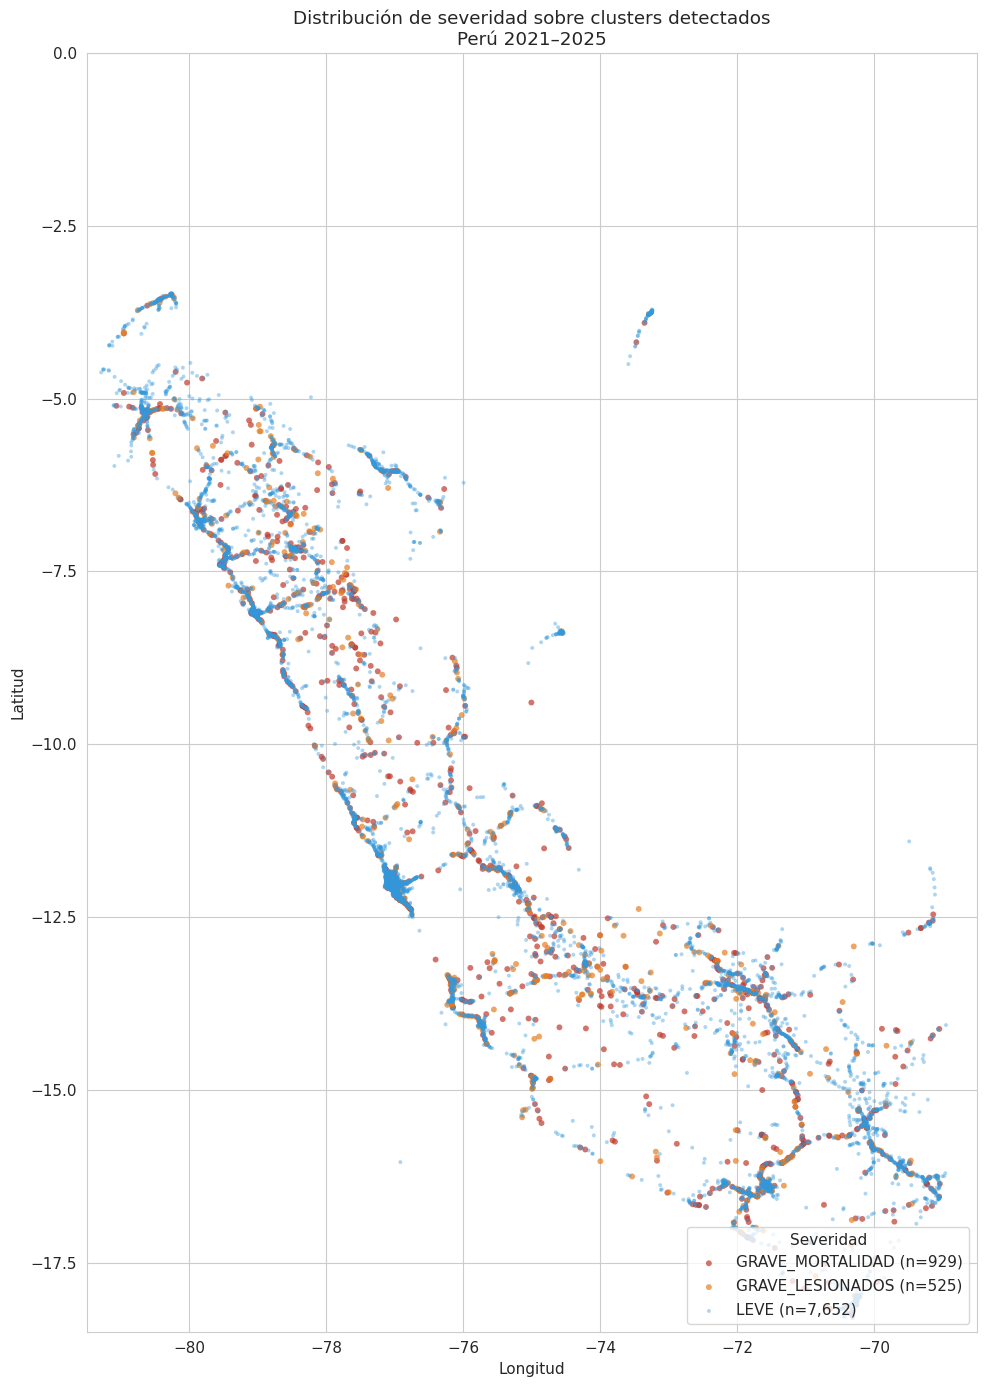

In [13]:
# Mapa 2: severidad sobre clusters
colores_sev = {
    'LEVE'             : '#3498db',
    'GRAVE_LESIONADOS' : '#e67e22',
    'GRAVE_MORTALIDAD' : '#c0392b'
}
orden_plot = ['GRAVE_MORTALIDAD', 'GRAVE_LESIONADOS', 'LEVE']

fig, ax = plt.subplots(figsize=(10, 14))

for categoria in orden_plot:
    if categoria not in df[col_target].values:
        continue
    subset = df[df[col_target] == categoria]
    ax.scatter(subset[col_lon], subset[col_lat],
               c=colores_sev.get(categoria, 'gray'),
               label=f'{categoria} (n={len(subset):,})',
               alpha=0.4 if categoria == 'LEVE' else 0.7,
               s=8 if categoria == 'LEVE' else 18,
               edgecolors='none')

ax.set_xlim(-81.5, -68.5)
ax.set_ylim(-18.5, -0.0)
ax.set_title('Distribución de severidad sobre clusters detectados\nPerú 2021–2025')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.legend(title='Severidad', loc='lower right')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / 'mapa_severidad_clusters.png', dpi=150)
plt.show()


## 8. Interpretación de resultados


In [14]:
# Resumen cuantitativo para la interpretación
print('=== Resumen para interpretación ===')
print(f'Total clusters:        {n_clusters}')
print(f'Total puntos en ruido: {n_ruido:,} ({n_ruido/len(df)*100:.1f}%)')

if col_grave:
    cluster_max_grave = resumen_clusters[col_grave].drop(-1, errors='ignore').idxmax()
    pct_max = resumen_clusters.loc[cluster_max_grave, col_grave]
    tam_max = resumen_clusters.loc[cluster_max_grave, 'TOTAL']
    print(f'\nCluster con mayor GRAVE_MORTALIDAD: Cluster {cluster_max_grave}')
    print(f'  Proporción: {pct_max:.1%}')
    print(f'  Tamaño: {tam_max:,} siniestros')
    
    # Centroide del cluster más grave
    centroide = df[df['CLUSTER'] == cluster_max_grave][[col_lat, col_lon]].mean()
    print(f'  Centroide aprox: lat={centroide[col_lat]:.3f}, lon={centroide[col_lon]:.3f}')


=== Resumen para interpretación ===
Total clusters:        3
Total puntos en ruido: 1 (0.0%)

Cluster con mayor GRAVE_MORTALIDAD: Cluster 0
  Proporción: 10.3%
  Tamaño: 8,997 siniestros
  Centroide aprox: lat=-11.367, lon=-75.680


## 9. Exportación

In [15]:
# Exportar dataset completo con cluster asignado
RUTA_SALIDA = DIR_PROCESADA / 'siniestros_clusters.csv'
df.to_csv(RUTA_SALIDA, index=False, encoding='utf-8')

# Exportar resumen de clusters
RUTA_RESUMEN = DIR_PROCESADA / 'resumen_clusters.csv'
resumen_clusters.to_csv(RUTA_RESUMEN, encoding='utf-8')

# Verificación
assert df['CLUSTER'].isnull().sum() == 0, 'Hay registros sin cluster asignado.'
assert len(df) == len(coords_orig), 'Se perdieron registros en el proceso.'

print('[SUCCESS] Archivos exportados:')
print(f'  {RUTA_SALIDA.name}  -> {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'  {RUTA_RESUMEN.name} -> {resumen_clusters.shape[0]} clusters × {resumen_clusters.shape[1]} columnas')
print(f'\nColumna CLUSTER: {df["CLUSTER"].nunique()} valores únicos')
print(f'  (-1 = ruido, 0..n = clusters detectados)')


[SUCCESS] Archivos exportados:
  siniestros_clusters.csv  -> 9,106 filas × 82 columnas
  resumen_clusters.csv -> 4 clusters × 4 columnas

Columna CLUSTER: 4 valores únicos
  (-1 = ruido, 0..n = clusters detectados)


## Referencias metodológicas

- **Ester et al. (1996)** - DBSCAN original; selección de parámetros via k-distance plot
- **Han, Kamber & Pei (2012)** - normalización previa a algoritmos basados en distancia
- **Kamh et al. (s.f.)** - aplicación de DBSCAN para detección de hotspots viales
